<a href="https://colab.research.google.com/github/owendouglas88/EMSC-W2-P1-u7947676/blob/main/EMSC2010_W5_L1_u7947676.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EMSC2010-W5-L1

## Random numbers
Below is some simple code to *generate uniformly* distributed random numbers. Don't worry about how the code works, we're just going to use it to demonstrate a concept.



In [1]:
class SimpleRNG:
    """
    A Linear Congruential Generator (LCG).
    Formula: next = (a * current + c) % m
    """
    def __init__(self, seed=42):
        self.state = seed
        self.a = 1664525      # Multiplier
        self.c = 1013904223   # Increment
        self.m = 2**32        # Modulus

    def next_int(self):
        """Generate the next raw integer."""
        self.state = (self.a * self.state + self.c) % self.m
        return self.state

    def next_float(self):
        """Generate a float in [0, 1)."""
        return self.next_int() / self.m

Generate 5 random numbers using a *seed* and print them to the screen

In [3]:
rng1 = SimpleRNG(seed=943590)
for _ in range(5):
    print(f"  rng1: {rng1.next_float():.6f}")

  rng1: 0.926663
  rng1: 0.444337
  rng1: 0.698231
  rng1: 0.940576
  rng1: 0.280244


### Using Numpy
Rather than writing our own code, we typically use a package like ```numpy``` to generate random numbers.

In [6]:
import numpy as np

# Create a generator with a fixed seed
rng = np.random.default_rng(seed=57)

# Generate an array of 5 numbers in [0, 1)
print(rng.uniform(size=5))

# Generate numbers in a custom range, e.g. [10, 20)
print(rng.uniform(low=2, high=100, size=10))

[0.6841667  0.46831197 0.84123367 0.34031981 0.39382159]
[17.33131449 44.0633775  73.1812647  30.50560941 35.03359483 20.38125514
 49.28750624 94.97517558 96.19688283 55.89508502]


In [14]:
import matplotlib.pyplot as plt

X=rng.uniform(size=100000)*10+10

(array([1943., 1941., 2089., 2046., 2031., 1995., 2017., 1980., 1941.,
        1953., 1994., 1973., 1953., 2017., 2045., 1940., 2022., 1994.,
        1992., 2087., 2064., 2005., 2007., 2012., 1968., 2098., 1978.,
        2028., 2091., 1986., 2049., 2008., 1963., 2029., 1962., 1967.,
        1876., 2037., 1902., 1923., 2029., 2029., 2053., 1990., 2028.,
        2043., 2001., 1951., 2027., 1943.]),
 array([10.00017896, 10.20017524, 10.40017151, 10.60016779, 10.80016407,
        11.00016034, 11.20015662, 11.40015289, 11.60014917, 11.80014544,
        12.00014172, 12.20013799, 12.40013427, 12.60013054, 12.80012682,
        13.00012309, 13.20011937, 13.40011564, 13.60011192, 13.80010819,
        14.00010447, 14.20010074, 14.40009702, 14.60009329, 14.80008957,
        15.00008584, 15.20008212, 15.40007839, 15.60007467, 15.80007094,
        16.00006722, 16.20006349, 16.40005977, 16.60005604, 16.80005232,
        17.00004859, 17.20004487, 17.40004115, 17.60003742, 17.8000337 ,
        18.00002

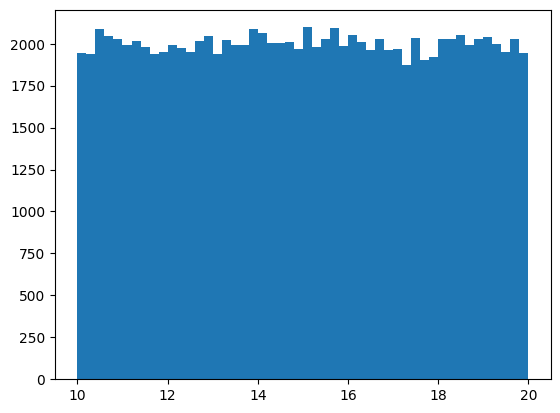

In [15]:
import matplotlib.pyplot as plt
plt.hist(X,bins=50)

In [29]:
#Area of a dartboard using a flow of random darts

Ntot = 1000000 #amount of darts thrown (n total)
X = rng.uniform(size=Ntot) #X pos of dart
Y = rng.uniform(size=Ntot) #Y pos of dart
D = np.sqrt((X-0.5)**2+(Y-0.5)**2) #determining if dart lands inside the board or outside it in the 1x1 grid
Nc = np.sum(D<0.5) #0.5=the radius of the circle, and adding up how many times a dart lands within this range
Ac = Nc*Ntot #area of the circle

print(Ac)
print(Nc)
print(np.pi*0.5**2) #the real area of a cirlce - the more trials that are done, the closer Ac gets to the true area

785605000000
785605
0.7853981633974483
